In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [31]:
# Exploratory Data Analysis(EDA):

In [32]:
df = pd.read_excel("/content/glass.xlsx", sheet_name='glass')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [34]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [35]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [36]:
#checking missing values, outliers, inconsistencies in the data
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [37]:
#Outliers
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_predictions = iso_forest.fit_predict(df)

outlier_indices = df.index[outlier_predictions == -1]

print(f"Number of detected outliers: {len(outlier_indices)}")

Number of detected outliers: 3


In [39]:
# Data Visualization

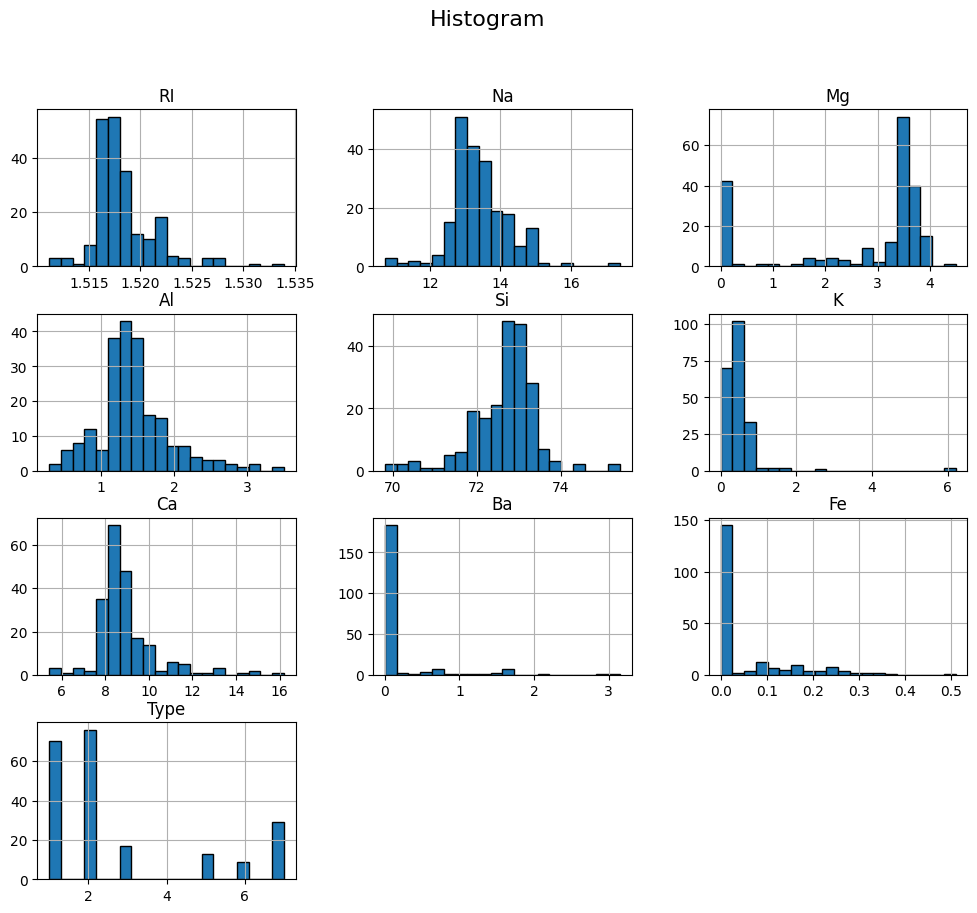

In [40]:
#Histogram
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Histogram", fontsize=16)
plt.show()

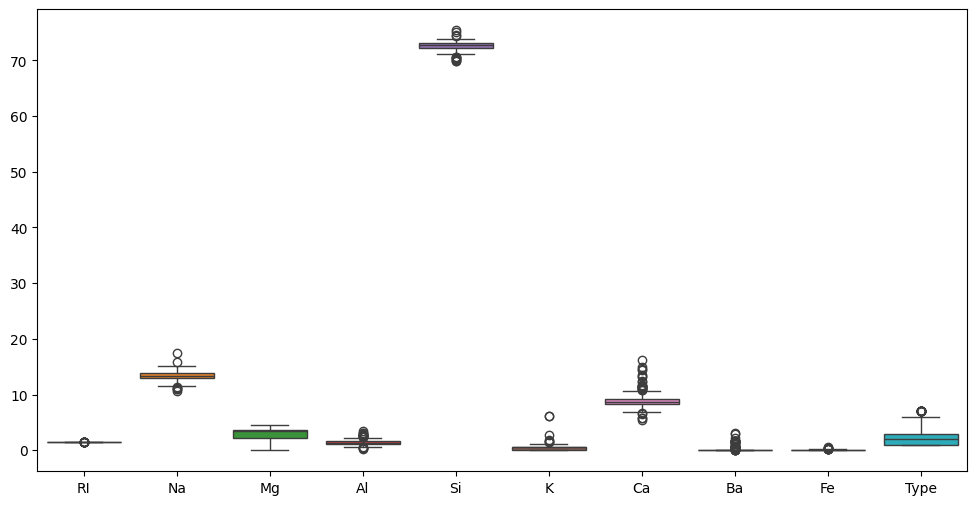

In [41]:
#box plots
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

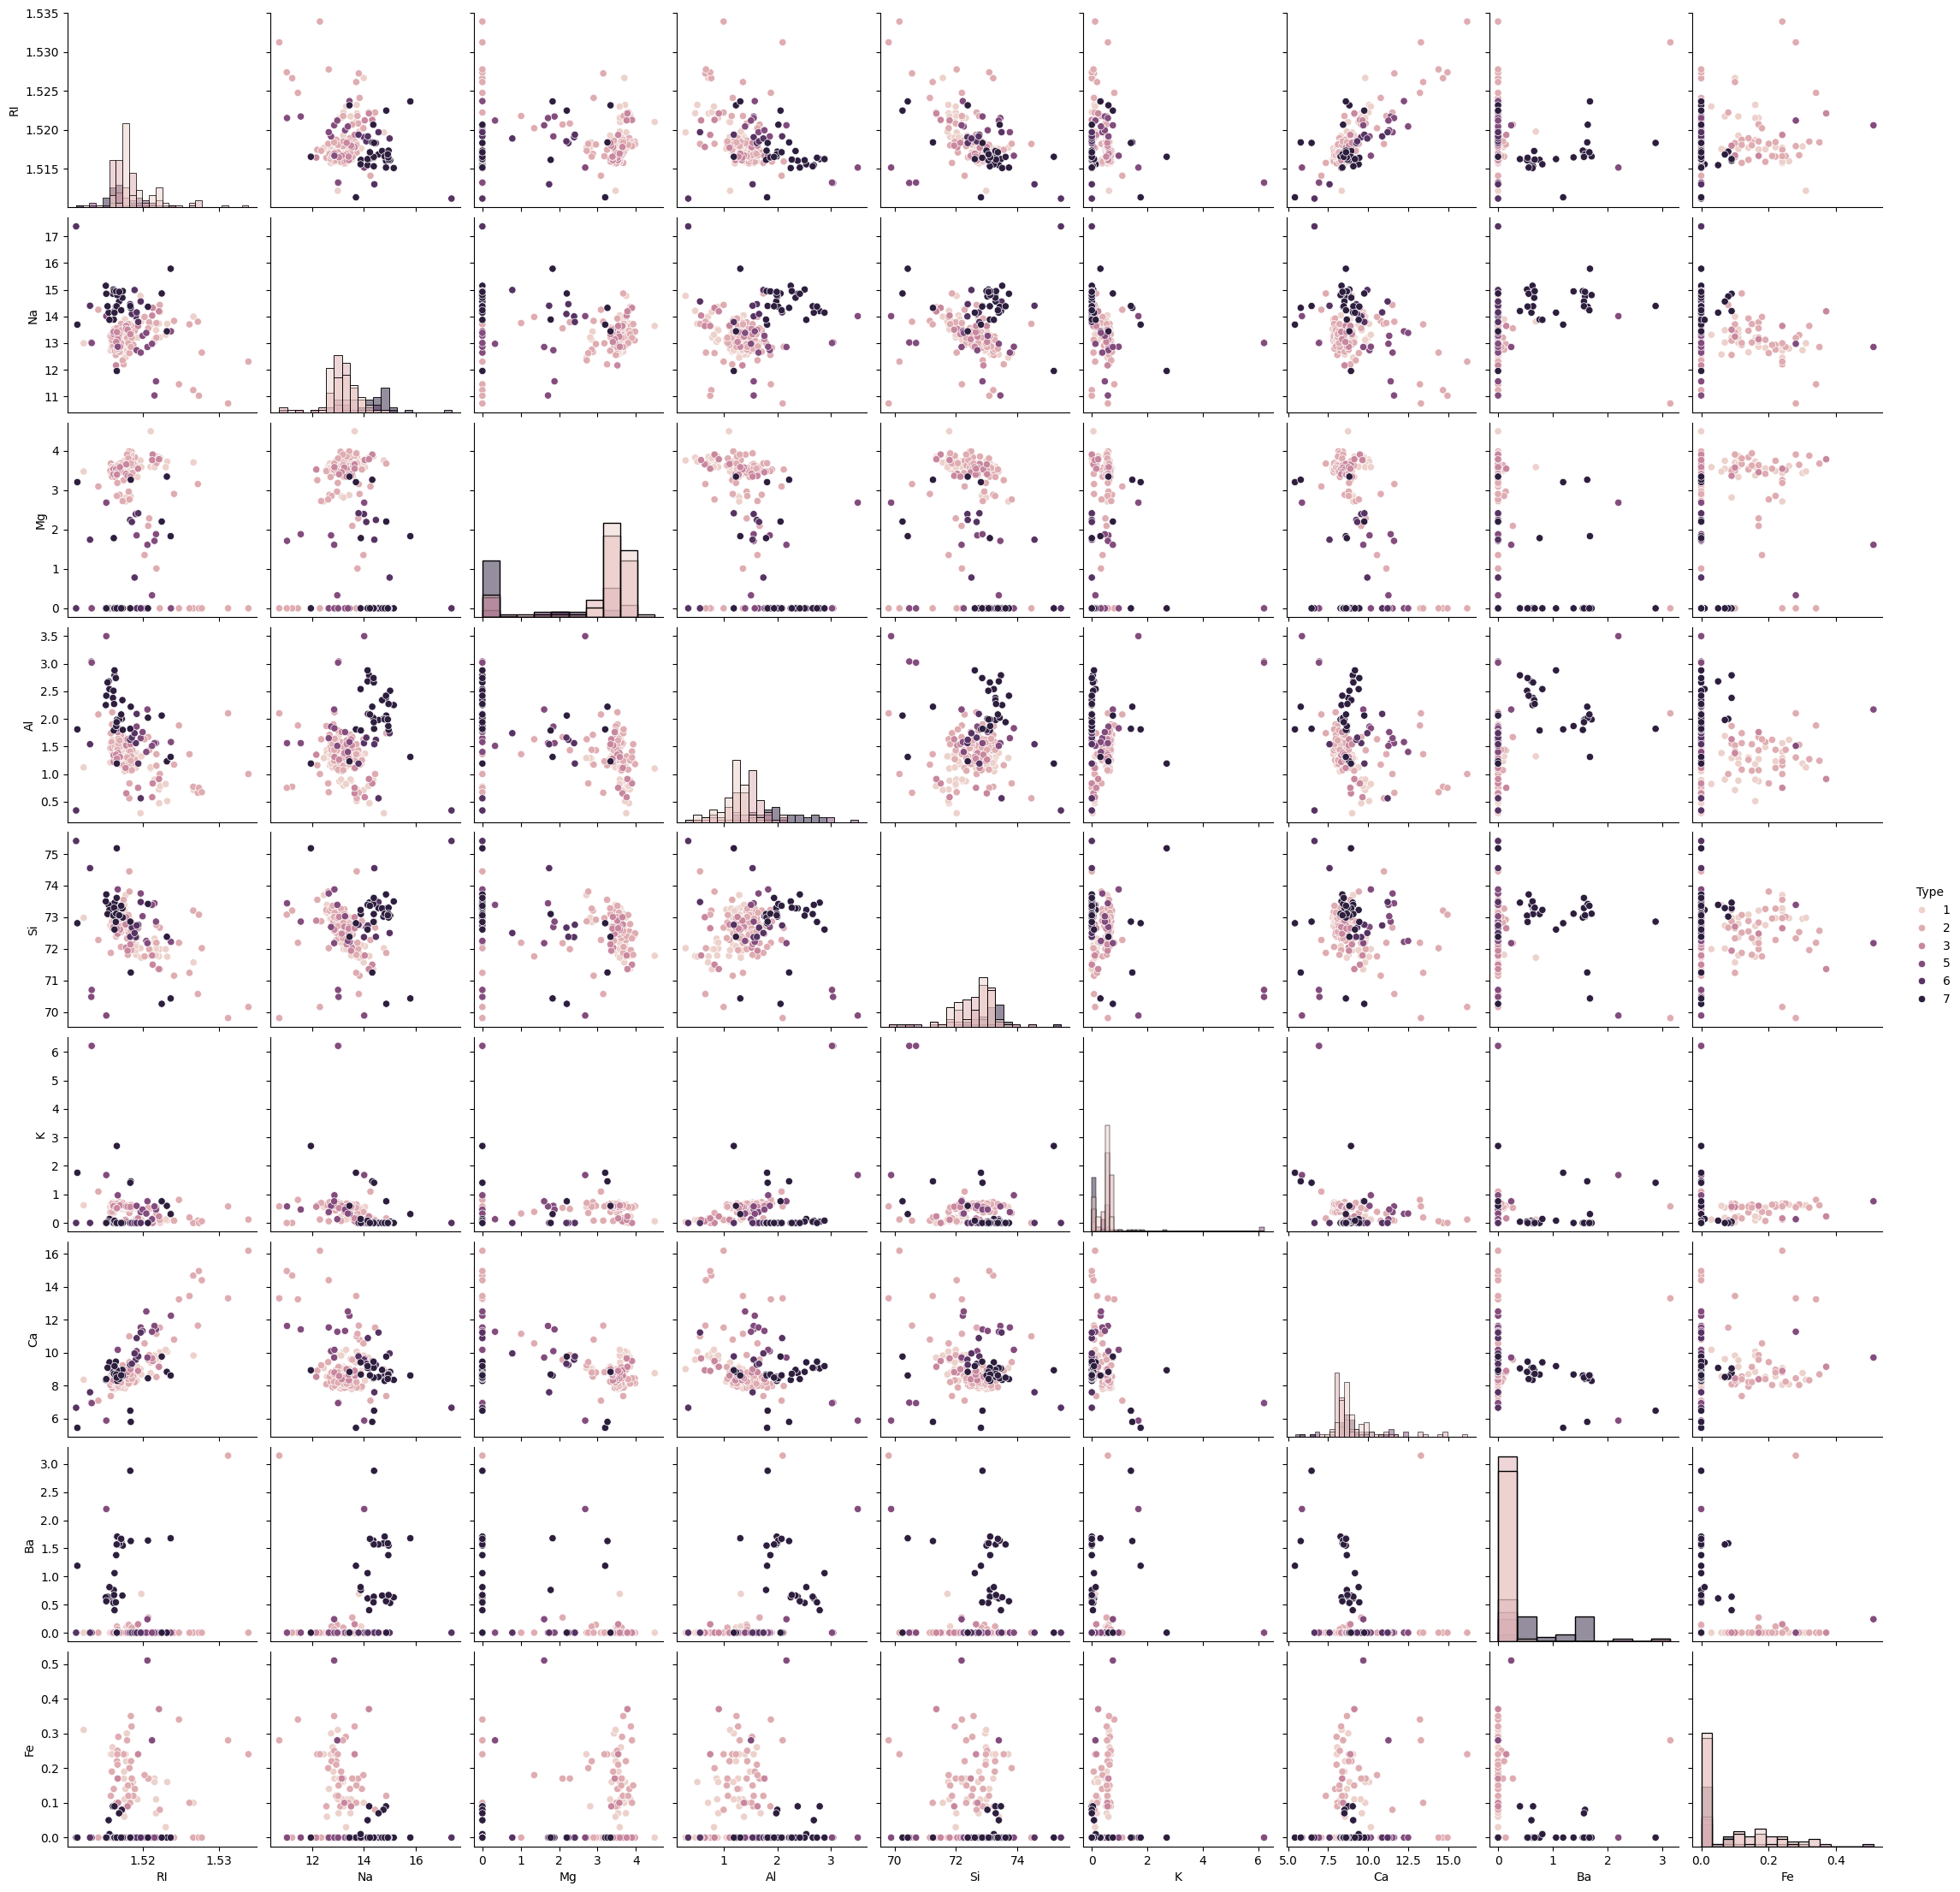

In [42]:
#pair plots
sns.pairplot(df, hue='Type',diag_kind='hist')
plt.show()

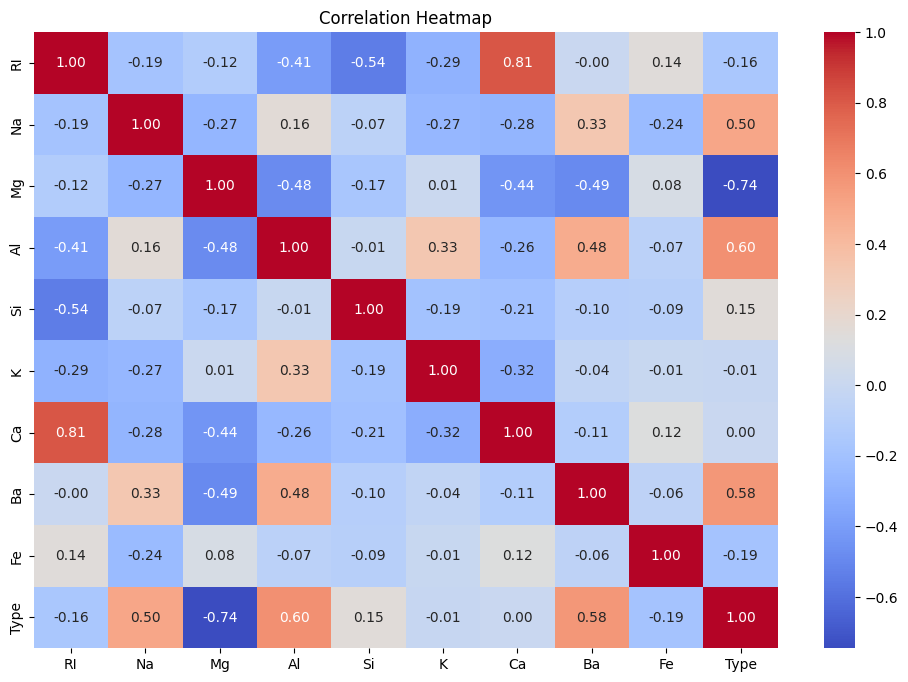

In [43]:
#correlation matrices.
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
# Correlation matrices show the high negative correlation between glass type and MG
# and High Positive correlation between glass type and AI

In [45]:
# Data Preprocessing

In [46]:
#Check for missing values in the dataset and decide on a strategy for handling them.
#Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [47]:
# there is no null value present in the dataset

In [48]:
#If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [49]:
# In the dataset no one categorical column present

In [50]:
#Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.
from sklearn.preprocessing import StandardScaler
X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()

X = scaler.fit_transform(X)
X = pd.DataFrame(X)
X.columns = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]
X

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451
...,...,...,...,...,...,...,...,...,...
209,-0.704815,0.898681,-1.865511,2.881125,-0.052974,-0.640968,0.157088,1.783978,-0.586451
210,-0.500178,1.856097,-1.865511,1.094342,0.529374,-0.763919,-0.392276,2.852405,-0.586451
211,0.754046,1.168721,-1.865511,1.154570,0.995252,-0.763919,-0.364103,2.953200,-0.586451
212,-0.612399,1.193270,-1.865511,0.993960,1.241133,-0.763919,-0.335931,2.812087,-0.586451


In [51]:
# Random Forest Model Implementation

In [52]:
#Divide the data into train and test split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
#Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
model = RandomForestClassifier()

In [54]:
#Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_score_train = accuracy_score(y_train, y_pred_train)
accuracy_score_test = accuracy_score(y_test, y_pred_test)

precision_score_train = precision_score(y_train, y_pred_train, average='weighted')
precision_score_test = precision_score(y_test, y_pred_test, average='weighted')

recall_score_train = recall_score(y_train, y_pred_train, average='weighted')
recall_score_test = recall_score(y_test, y_pred_test, average='weighted')

f1_score_train = f1_score(y_train, y_pred_train, average='weighted')
f1_score_test = f1_score(y_test, y_pred_test, average='weighted')

In [55]:
print("accuracy_score_train:",accuracy_score_train)
print("accuracy_score_test:",accuracy_score_test)
print("precision_score_train:",precision_score_train)
print("precision_score_test:",precision_score_test)
print("recall_score_train:",recall_score_train)
print("recall_score_test:",recall_score_test)
print("f1_score_train:",f1_score_train)
print("f1_score_test:",f1_score_test)

accuracy_score_train: 1.0
accuracy_score_test: 0.8837209302325582
precision_score_train: 1.0
precision_score_test: 0.8895845756310872
recall_score_train: 1.0
recall_score_test: 0.8837209302325582
f1_score_train: 1.0
f1_score_test: 0.8811039621573137


In [56]:
# Bagging and Bossting Methods

In [57]:
#Apply the Bagging and Boosting methods and compare the results.
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

In [58]:
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy  Precision    Recall  F1-Score
0      Random Forest  0.837209   0.866828  0.837209  0.833045
1            Bagging  0.860465   0.860029  0.860465  0.851382
2           AdaBoost  0.627907   0.613999  0.627907  0.613924
3  Gradient Boosting  0.860465   0.879937  0.860465  0.850129


In [59]:
#Additional Notes:

In [60]:
#1. Explain Bagging and Boosting methods. How is it different from each other.
#Ans:- Bagging bulid the model independently and its reduces the variance
#      Boosting bulid the model sequentially and its reduces the bias.

In [61]:
#2. Explain how to handle imbalance in the data.
#Ans:- For anhdling the imbalance